In [ ]:
# Part 14 — Full Pipeline: Image -> Text -> Custom Audio (Fully Contained)
import os
import torch
import soundfile as sf
import librosa
from transformers import pipeline, SpeechT5ForTextToSpeech, SpeechT5Processor, SpeechT5HifiGan
from speechbrain.pretrained import EncoderClassifier

# Create a dedicated local folder for downloaded models in your main project directory
local_model_dir = "../local_models"
hf_cache_dir = f"{local_model_dir}/huggingface"
os.makedirs(hf_cache_dir, exist_ok=True)


# 1. Load the Image Captioning Model (Offline Mode)
print("Loading image captioning model...")
captioner = pipeline(
    "image-to-text", 
    model="nlpconnect/vit-gpt2-image-captioning", 
    device="cuda" if torch.cuda.is_available() else "cpu",
    model_kwargs={"cache_dir": hf_cache_dir},
    #local_files_only=True  # This forces offline mode
)

# 2. Load your Fine-Tuned TTS Model 
print("Loading your fine-tuned TTS model...")
model_path = "../speecht5_finetuned_ljspeech/final" 
processor = SpeechT5Processor.from_pretrained(model_path) # Already local
model = SpeechT5ForTextToSpeech.from_pretrained(model_path) # Already local

# Load Vocoder (Saves to ../local_models/huggingface)
vocoder = SpeechT5HifiGan.from_pretrained(
    "microsoft/speecht5_hifigan", 
    cache_dir=hf_cache_dir,
    #local_files_only=True
    # Add local_files_only=True here AFTER the first successful download
)

# 3. Load the Real Voice Profile from your LJSpeech folder
print("Loading the human voice profile...")
spk_model = EncoderClassifier.from_hparams(
    source="speechbrain/spkrec-xvect-voxceleb",
    savedir=f"{local_model_dir}/speechbrain_voxceleb", # Saves to ../local_models/speechbrain_voxceleb
    run_opts={"device": "cuda" if torch.cuda.is_available() else "cpu"}
)

# Go up one level to find the LJSpeech folder
audio_array, _ = librosa.load("../LJSpeech-1.1/wavs/LJ001-0001.wav", sr=16000)
audio_tensor = torch.tensor(audio_array).unsqueeze(0).float().to(spk_model.device)

with torch.no_grad():
    embedding = spk_model.encode_batch(audio_tensor)
    embedding = torch.nn.functional.normalize(embedding, dim=2)
    speaker_embeddings = embedding.squeeze().unsqueeze(0).to(model.device)

print("\n--- Pipeline Ready ---")

Loading image captioning model...


Special tokens have been added in the vocabulary, make sure the associated word embeddings are fine-tuned or trained.


Loading your fine-tuned TTS model...
Loading the human voice profile...

--- Pipeline Ready ---


In [1]:
# Part 14 — Full Pipeline: Image -> Text -> Custom Audio (Strict Offline Mode)
import os
import torch
import soundfile as sf
import librosa
from transformers import (
    pipeline, 
    SpeechT5ForTextToSpeech, 
    SpeechT5Processor, 
    SpeechT5HifiGan,
    VisionEncoderDecoderModel,
    AutoImageProcessor,
    AutoTokenizer
)
from speechbrain.pretrained import EncoderClassifier

# Point to your dedicated local folder
local_model_dir = "../local_models"
hf_cache_dir = f"{local_model_dir}/huggingface"

# 1. Load the Image Captioning Model (Explicit Offline Mode)
print("Loading image captioning model offline...")
model_id = "nlpconnect/vit-gpt2-image-captioning"

# Load components explicitly from the local cache to bypass pipeline network checks
image_processor = AutoImageProcessor.from_pretrained(model_id, cache_dir=hf_cache_dir, local_files_only=True)
tokenizer = AutoTokenizer.from_pretrained(model_id, cache_dir=hf_cache_dir, local_files_only=True)
caption_model = VisionEncoderDecoderModel.from_pretrained(model_id, cache_dir=hf_cache_dir, local_files_only=True)

captioner = pipeline(
    "image-to-text", 
    model=caption_model, 
    image_processor=image_processor, 
    tokenizer=tokenizer,
    device="cuda" if torch.cuda.is_available() else "cpu"
)

# 2. Load your Fine-Tuned TTS Model 
print("Loading your fine-tuned TTS model...")
model_path = "../speecht5_finetuned_ljspeech/final" 
processor = SpeechT5Processor.from_pretrained(model_path) # Already local
model = SpeechT5ForTextToSpeech.from_pretrained(model_path) # Already local

# Load Vocoder (Offline Mode)
print("Loading vocoder offline...")
vocoder = SpeechT5HifiGan.from_pretrained(
    "microsoft/speecht5_hifigan", 
    cache_dir=hf_cache_dir,
    local_files_only=True
)

# 3. Load the Real Voice Profile from your LJSpeech folder
print("Loading the human voice profile...")
spk_model = EncoderClassifier.from_hparams(
    source="speechbrain/spkrec-xvect-voxceleb",
    savedir=f"{local_model_dir}/speechbrain_voxceleb", 
    run_opts={"device": "cuda" if torch.cuda.is_available() else "cpu"}
)

# Go up one level to find the LJSpeech folder
audio_array, _ = librosa.load("../LJSpeech-1.1/wavs/LJ001-0001.wav", sr=16000)
audio_tensor = torch.tensor(audio_array).unsqueeze(0).float().to(spk_model.device)

with torch.no_grad():
    embedding = spk_model.encode_batch(audio_tensor)
    embedding = torch.nn.functional.normalize(embedding, dim=2)
    speaker_embeddings = embedding.squeeze().unsqueeze(0).to(model.device)

print("\n--- Pipeline Ready ---")

The torchaudio backend is switched to 'soundfile'. Note that 'sox_io' is not supported on Windows.
c:\Users\subra\AppData\Local\Programs\Python\Python310\lib\site-packages\speechbrain\utils\torch_audio_backend.py:22: UserWarning: torchaudio._backend.set_audio_backend has been deprecated. With dispatcher enabled, this function is no-op. You can remove the function call.
  torchaudio.set_audio_backend("soundfile")
The torchaudio backend is switched to 'soundfile'. Note that 'sox_io' is not supported on Windows.


Loading image captioning model offline...


Special tokens have been added in the vocabulary, make sure the associated word embeddings are fine-tuned or trained.


Loading your fine-tuned TTS model...
Loading vocoder offline...
Loading the human voice profile...

--- Pipeline Ready ---


In [ ]:
# 4. The Processing Engine 
def generate_caption_and_audio(image_path):
    print(f"\nProcessing image: {image_path}")
    
    print("1. Generating caption...")
    result = captioner(image_path)
    caption_text = result[0]['generated_text']
    print(f"   Result: '{caption_text}'")
    
    # Saves inside the 'pipeline' folder
    text_filename = "output_caption.txt"
    with open(text_filename, "w") as f:
        f.write(caption_text)
    print(f"2. Caption saved to {text_filename}")
    
    print("3. Generating audio...")
    inputs = processor(text=caption_text, return_tensors="pt")
    
    with torch.no_grad():
        speech = model.generate_speech(inputs["input_ids"].to(model.device), speaker_embeddings, vocoder=vocoder)
    
    # Saves inside the 'pipeline' folder
    audio_filename = "output_audio.wav"
    sf.write(audio_filename, speech.cpu().numpy(), samplerate=16000)
    print(f"4. Audio saved to {audio_filename}")
    
    print("\nProcess Complete!")

# 5. Test the Engine! 
my_image_path = "../custom_img/10.jpg"
generate_caption_and_audio(my_image_path)


Processing image: ../roc, confusion matrix\dog\dog.8401.jpg
1. Generating caption...


c:\Users\subra\AppData\Local\Programs\Python\Python310\lib\site-packages\transformers\generation\utils.py:1168: UserWarning: Using the model-agnostic default `max_length` (=20) to control the generation length. We recommend setting `max_new_tokens` to control the maximum length of the generation.
  warnings.warn(


   Result: 'a dog is looking at the camera while standing in a fence '
2. Caption saved to output_caption.txt
3. Generating audio...
4. Audio saved to output_audio.wav

Process Complete!


Fetching results...


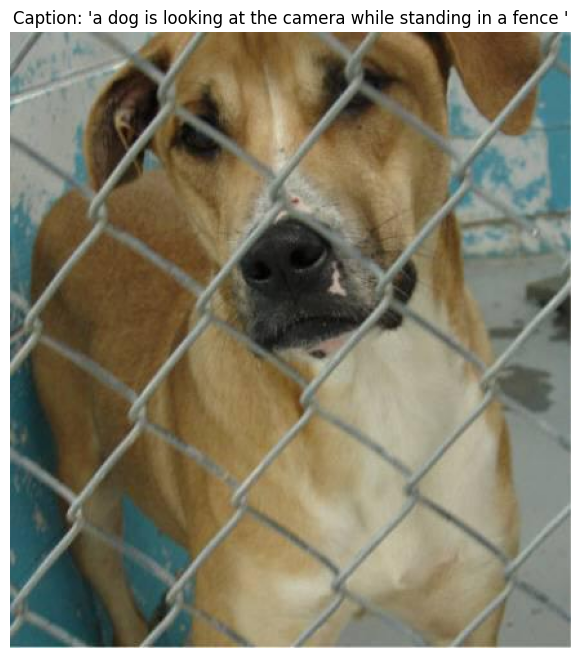


Listen to the generated audio:


In [7]:
# Part 15 — Displaying the Final Output
import matplotlib.pyplot as plt
from PIL import Image
import requests
from io import BytesIO
from IPython.display import Audio, display

print("Fetching results...")

# 1. Read the caption we just saved
with open("output_caption.txt", "r") as f:
    saved_caption = f.read()

# 2. Load the image (this handles both web URLs and local files safely)
if my_image_path.startswith("http"):
    response = requests.get(my_image_path)
    img = Image.open(BytesIO(response.content))
else:
    img = Image.open(my_image_path)

# 3. Display the Image with the Caption as the title
plt.figure(figsize=(8, 8))
plt.imshow(img)
plt.axis('off') # Hides the grid lines
#plt.title(f"Generated Caption: '{saved_caption}'", fontsize=12, wrap=range, color="red")
plt.title(f"Caption: '{saved_caption}'", fontsize=12, wrap=range, color="black")
plt.show()

# 4. Embed a playable audio widget!
print("\nListen to the generated audio:")
display(Audio("output_audio.wav"))

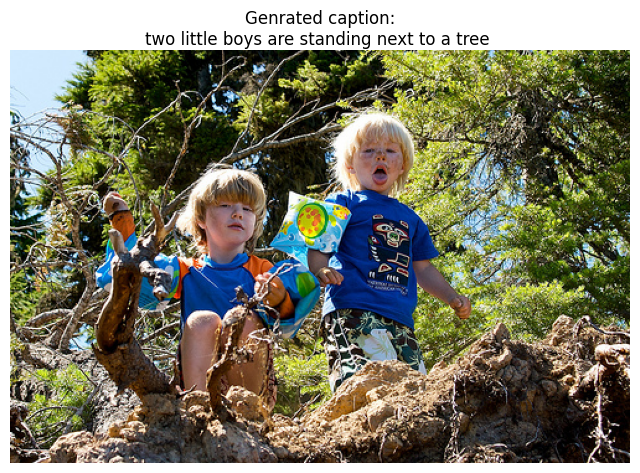

In [ ]:
# ONLY IMAGE TO CAPTION

import torch
from PIL import Image
import matplotlib.pyplot as plt
from transformers import pipeline, VisionEncoderDecoderModel, AutoImageProcessor, AutoTokenizer

local_model_dir = "../local_models"
hf_cache_dir = f"{local_model_dir}/huggingface"
model_id = "nlpconnect/vit-gpt2-image-captioning"

# 1. Load Model Offline
image_processor = AutoImageProcessor.from_pretrained(model_id, cache_dir=hf_cache_dir, local_files_only=True)
tokenizer = AutoTokenizer.from_pretrained(model_id, cache_dir=hf_cache_dir, local_files_only=True)
caption_model = VisionEncoderDecoderModel.from_pretrained(model_id, cache_dir=hf_cache_dir, local_files_only=True)

captioner = pipeline(
    "image-to-text", 
    model=caption_model, 
    image_processor=image_processor, 
    tokenizer=tokenizer,
    device="cuda" if torch.cuda.is_available() else "cpu"
)

# 2. Processing Function
def generate_and_display_caption(image_path):
    result = captioner(image_path)
    caption_text = result[0]['generated_text']
    
    # Display in Notebook
    img = Image.open(image_path)
    plt.figure(figsize=(8, 6))
    plt.imshow(img)
    plt.axis('off')
    plt.title(f'Genrated caption:\n{caption_text}', fontsize=12, color="black", wrap=True)
    plt.show()

# 3. Test
my_image_path = "../custom_img/10.jpg"
generate_and_display_caption(my_image_path)

In [1]:
# ONLY SPEECH TO TEXT

import torch
import librosa
from IPython.display import Audio, display
from transformers import SpeechT5ForTextToSpeech, SpeechT5Processor, SpeechT5HifiGan
from speechbrain.pretrained import EncoderClassifier

local_model_dir = "../local_models"
hf_cache_dir = f"{local_model_dir}/huggingface"

# 1. Load Models Offline
model_path = "../speecht5_finetuned_ljspeech/final" 
processor = SpeechT5Processor.from_pretrained(model_path)
model = SpeechT5ForTextToSpeech.from_pretrained(model_path)
vocoder = SpeechT5HifiGan.from_pretrained(
    "microsoft/speecht5_hifigan", cache_dir=hf_cache_dir, local_files_only=True
)

spk_model = EncoderClassifier.from_hparams(
    source="speechbrain/spkrec-xvect-voxceleb",
    savedir=f"{local_model_dir}/speechbrain_voxceleb", 
    run_opts={"device": "cuda" if torch.cuda.is_available() else "cpu"}
)

# 2. Extract Voice Profile
audio_array, _ = librosa.load("../LJSpeech-1.1/wavs/LJ001-0001.wav", sr=16000)
audio_tensor = torch.tensor(audio_array).unsqueeze(0).float().to(spk_model.device)

with torch.no_grad():
    embedding = spk_model.encode_batch(audio_tensor)
    embedding = torch.nn.functional.normalize(embedding, dim=2)
    speaker_embeddings = embedding.squeeze().unsqueeze(0).to(model.device)

# 3. Processing Function
def generate_and_play_audio(text):
    inputs = processor(text=text, return_tensors="pt")
    
    with torch.no_grad():
        speech = model.generate_speech(inputs["input_ids"].to(model.device), speaker_embeddings, vocoder=vocoder)
    
    # Display Playable Widget in Notebook
    display(Audio(data=speech.cpu().numpy(), rate=16000))

# 4. Test
#my_text = "Printing, in the only sense with which we are at present concerned, differs from most if not from all the arts and crafts represented in the Exhibition "
my_text = "i am giving a presentation"
generate_and_play_audio(my_text)

The torchaudio backend is switched to 'soundfile'. Note that 'sox_io' is not supported on Windows.
c:\Users\subra\AppData\Local\Programs\Python\Python310\lib\site-packages\speechbrain\utils\torch_audio_backend.py:22: UserWarning: torchaudio._backend.set_audio_backend has been deprecated. With dispatcher enabled, this function is no-op. You can remove the function call.
  torchaudio.set_audio_backend("soundfile")
The torchaudio backend is switched to 'soundfile'. Note that 'sox_io' is not supported on Windows.
c:\Users\subra\AppData\Local\Programs\Python\Python310\lib\site-packages\speechbrain\utils\torch_audio_backend.py:22: UserWarning: torchaudio._backend.set_audio_backend has been deprecated. With dispatcher enabled, this function is no-op. You can remove the function call.
  torchaudio.set_audio_backend("soundfile")
Special tokens have been added in the vocabulary, make sure the associated word embeddings are fine-tuned or trained.
